# Testing Model

En este notebook se realizarán pruebas del modelo de clusterización bioinspirado con diferentes funciones de distancia y métodos de selección de características con el objetivo de encontrar la combinación que maximize el rendimiento del algoritmo usando el coeficiente de Silhouette para medir la calidad de la clusterización realizada.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Distancia Euclidiana


In [24]:
# Algoritmo bioinspirado en la expansión del reino fungi
class FungiInspiredClustering:
    def __init__(self,Distance_Function, n_clusters=5, max_iter=100, local_radius=1.0, global_radius=5.0, tolerance=1e-4):
        self.Distance_Function = Distance_Function
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.local_radius = local_radius
        self.global_radius = global_radius
        self.tolerance = tolerance

    def fit(self, X):
        # Inicializar las "esporas" (centroides iniciales) aleatoriamente
        np.random.seed(42)  # Para reproducibilidad
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iter):
            # Fase 1: Expansión local (caótica)
            self.labels = self.assign_local_clusters(X)

            # Fase 2: Reajuste global (dirigida)
            old_centroids = self.centroids.copy()
            self.centroids = self.calculate_new_centroids(X)

            # Verificar convergencia
            if self.has_converged(old_centroids):
                print(f"Convergencia alcanzada en la iteración {i+1}")
                break

    def assign_local_clusters(self, X):
        labels = []
        for point in X:
            distances = [self.Distance_Function(point, centroid) for centroid in self.centroids]

            # Expansión local caótica: Agregar ruido a la distancia para simular crecimiento aleatorio
            noisy_distances = [dist + np.random.uniform(-self.local_radius, self.local_radius) for dist in distances]
            labels.append(np.argmin(noisy_distances))
        return np.array(labels)

    def calculate_new_centroids(self, X):
        centroids = []
        for i in range(self.n_clusters):
            points_in_cluster = X[self.labels == i]
            if len(points_in_cluster) > 0:
                # Expansión global: Ajuste de los centroides hacia áreas ricas en puntos
                new_centroid = points_in_cluster.mean(axis=0) + np.random.uniform(-self.global_radius, self.global_radius, size=points_in_cluster.shape[1])
            else:
                # Si el clúster está vacío, reasignar un centroide aleatorio
                new_centroid = X[np.random.choice(X.shape[0])]
            centroids.append(new_centroid)
        return np.array(centroids)

    def has_converged(self, old_centroids):
        # Verificar si los centroides han cambiado por menos de la tolerancia
        distances = [self.Distance_Function(old, new) for old, new in zip(old_centroids, self.centroids)]
        return np.max(distances) < self.tolerance

In [25]:
# Cargar el dataset
file_path = 'CleanDataset.csv'
df = pd.read_csv(file_path)

Coeficiente de Silhouette: 0.27316512494551515

Centroides finales:
[[ 3.30736751e+03  6.01404123e+03  1.54617309e+00  8.95367522e+02
   4.94554243e+02  4.01724292e+02  4.77616679e+03 -6.22898184e-01
   1.99208474e+00  8.72218024e-01  1.43079829e+00  1.29756375e+01
   1.43615879e+01  9.56538302e+03  3.81292963e+03  6.65860589e-02
   1.17711359e+01]
 [ 3.19716790e+03  1.53032806e+03  1.46127475e+00  1.98738640e+03
   1.26991499e+03  7.21430008e+02  4.15930851e+02 -1.22779539e+00
  -1.28981705e+00  8.15222986e-01 -1.04814577e+00  3.13420355e+00
   2.57624597e+01  8.54879388e+03  2.32252118e+03  1.39394971e+00
   1.02630323e+01]
 [ 6.96682664e+03  7.49877822e+02  2.54636520e+00  5.28411103e+02
   2.45419898e+02  2.85590250e+02  5.53761061e+02  5.42560641e-01
  -1.14673840e+00  1.34325228e+00  3.68255634e-01  3.12191493e+00
   1.16622845e+01  2.37776549e+03  9.08648768e+02 -1.85544490e-02
   1.18097948e+01]
 [ 2.39927145e+03  1.19974751e+03 -1.18801046e-01  6.05414758e+02
   3.37468864e+02

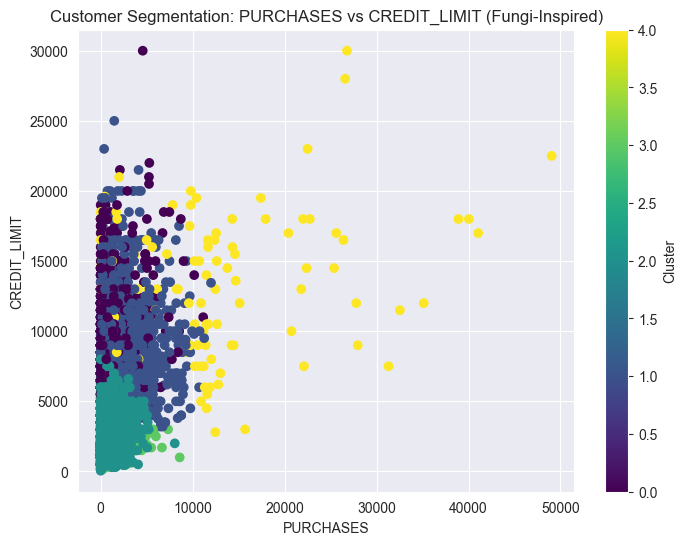

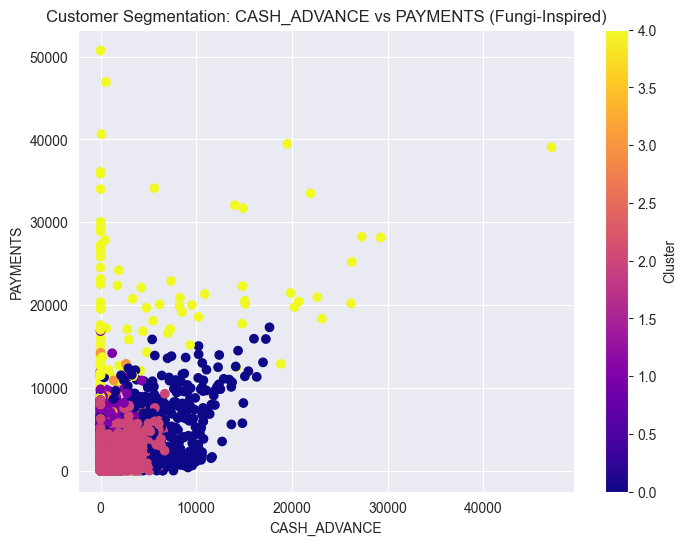

In [26]:
# Función para calcular la distancia euclidiana entre dos puntos
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(euclidean_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.38328876816870766

Centroides finales:
[[ 3.34455241e+03  5.42245639e+03  1.48083279e+00  1.31109887e+03
   6.18977546e+02  6.93114997e+02  1.05661728e+04 -6.20437881e-01
   2.00271100e+00  8.82588570e-01  1.53111090e+00  2.15684793e+01
   1.92740483e+01  1.06930204e+04  1.37614892e+04  1.74832606e-01
   1.18508965e+01]
 [ 2.79218435e+03  3.68849951e+03  1.49649039e+00  8.66332050e+02
   5.10004797e+02  3.59939629e+02  2.24016327e+03 -1.42735067e+00
  -1.45445649e+00  6.65200330e-01 -8.75675799e-01  7.92876087e+00
   1.31768452e+01  8.94646636e+03  2.21900379e+03  1.25293830e+00
   1.01273572e+01]
 [ 5.03324387e+03  8.55473113e+02  2.56134688e+00  5.81651362e+02
   2.93822204e+02  2.90228903e+02  5.07945049e+02  5.38941383e-01
  -1.11861128e+00  1.32439257e+00  3.57945721e-01  2.78472887e+00
   1.22056536e+01  2.89090194e+03  9.98501893e+02 -2.84336954e-02
   1.19932998e+01]
 [ 3.01312124e+03  2.69287699e+03 -2.77059866e-02  5.92089622e+03
   3.95567525e+03

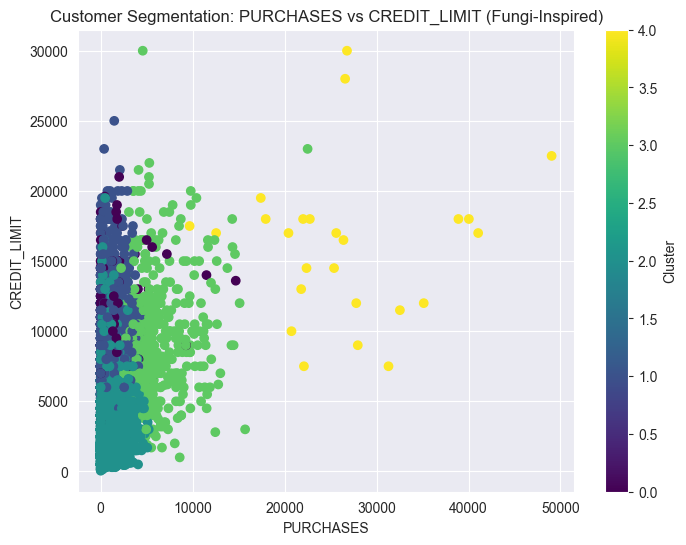

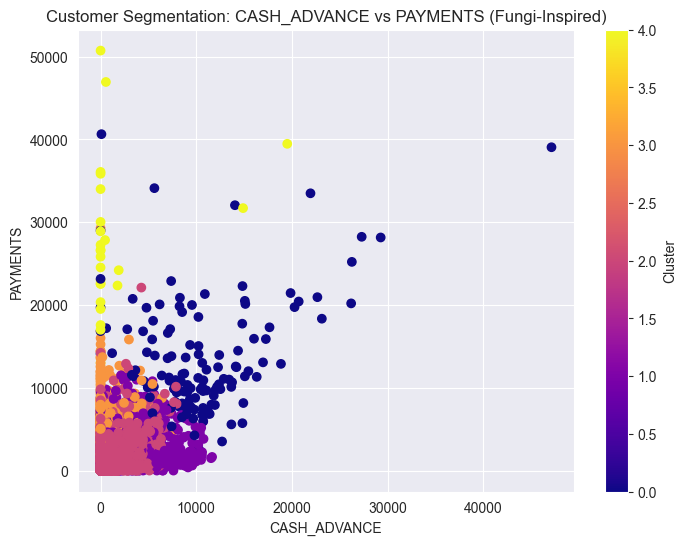

In [27]:
#Función para la distancia Manhattan
def manhattan_distance(point1, point2):
    return np.sum(np.abs(point1 - point2))
df = pd.read_csv(file_path)
# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(manhattan_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.2561777680713325

Centroides finales:
[[ 2.98843216e+03  4.80087252e+03  1.52107151e+00  1.63077472e+03
   1.02643454e+03  6.05229529e+02  3.16134111e+03 -4.78010260e-01
   2.11605277e+00  9.67033322e-01  1.30257626e+00  8.90229740e+00
   2.23518706e+01  1.08522422e+04  3.54654677e+03  1.39663728e-01
   1.18646786e+01]
 [ 3.58151212e+03  1.60940168e+03  1.45460695e+00  1.36625371e+03
   8.45511687e+02  5.24777453e+02  8.04217962e+02 -1.33305744e+00
  -1.38816974e+00  7.37582094e-01 -1.00172971e+00  4.34719049e+00
   1.86693355e+01  6.50829246e+03  1.96894151e+03  1.35938164e+00
   1.02096441e+01]
 [ 7.08438479e+03  7.03259659e+02  2.54516454e+00  5.08116900e+02
   2.28446087e+02  2.82202994e+02  5.15540968e+02  5.47011079e-01
  -1.15043570e+00  1.34976485e+00  3.66305120e-01  3.05883161e+00
   1.15115061e+01  2.16114275e+03  8.55054301e+02 -2.11986511e-02
   1.17788035e+01]
 [ 2.40584056e+03  1.01302881e+03 -1.22280987e-01  5.15946134e+02
   2.72432382e+02 

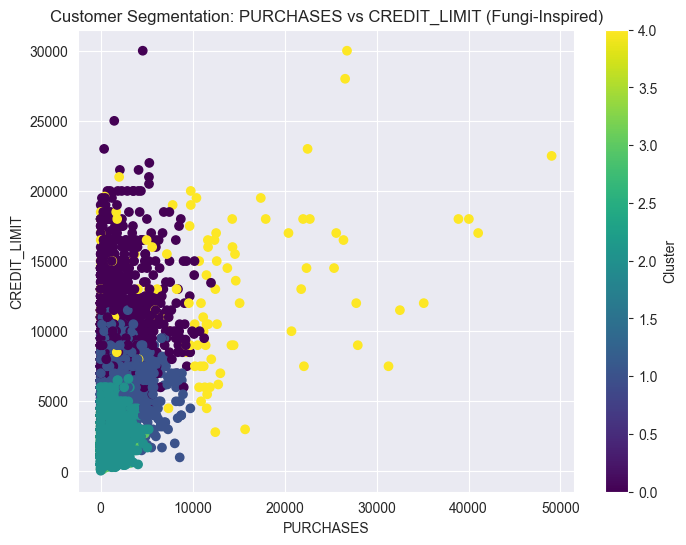

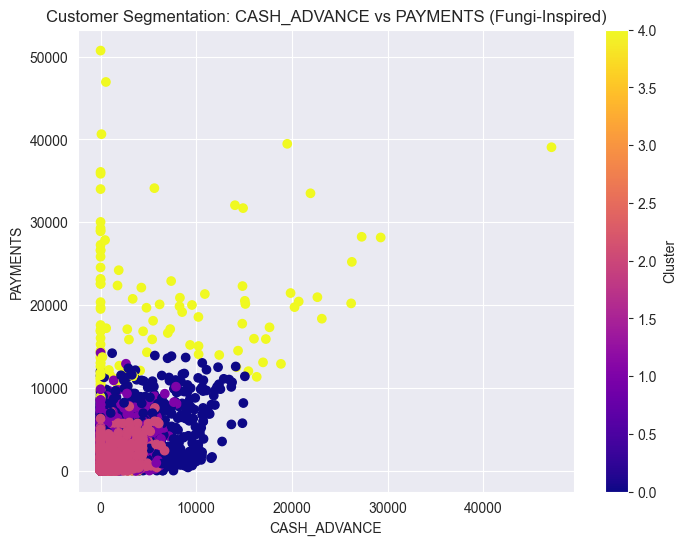

In [28]:
def minkowski_distance(point1, point2, p=3):
    return np.sum(np.abs(point1 - point2) ** p) ** (1 / p)
# Aplicar nuestro algoritmo FungiInspiredClustering
df = pd.read_csv(file_path)
n_clusters = 5
fungi_clustering = FungiInspiredClustering(minkowski_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

# Eliminando características según la matriz de correlación

In [30]:
df = pd.read_csv(file_path)
df= df.drop(columns=['ONEOFF_PURCHASES','PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_TRX','INSTALLMENTS_PURCHASES','CASH_ADVANCE','BALANCE_FREQUENCY'])

Coeficiente de Silhouette: 0.2994463777151012

Centroides finales:
[[ 2.84494284e+03  5.24297870e+03  2.02944516e+03  9.09346240e-02
  -1.65075089e+00 -1.64051118e+00  2.68154856e+01  1.20372870e+04
   3.78020670e+03 -1.19012098e+00  1.16844601e+01  3.70106938e-02]
 [ 3.41952415e+03  1.97589949e+03  1.32586809e+03  1.79055228e+00
   1.02052842e+00  4.94027816e-01  1.95227929e+01  6.96544646e+03
   2.13940478e+03  7.12536273e-01  1.19059057e+01  2.55162479e+00]
 [ 7.01947246e+03  7.22657248e+02  5.28202416e+02  1.82371300e+00
   1.91772164e+00  1.98546081e+00  8.29296231e+00  2.26443656e+03
   9.11518960e+02 -1.12324608e+00  9.35103126e+00  4.55180900e-01]
 [ 2.38465573e+03  1.02678112e+03  5.65062615e+02  1.52435345e+00
  -1.31370415e+00 -8.54840247e-01  1.10109055e+01  2.48433223e+03
   9.96161216e+02 -1.10881824e+00  1.02915982e+01  1.57382848e+00]
 [ 2.44722632e+03  4.60973325e+03  1.08022838e+04  1.76135457e-01
   1.97954048e+00  1.38679163e+00  8.21898638e+01  1.26393686e+04
   1.

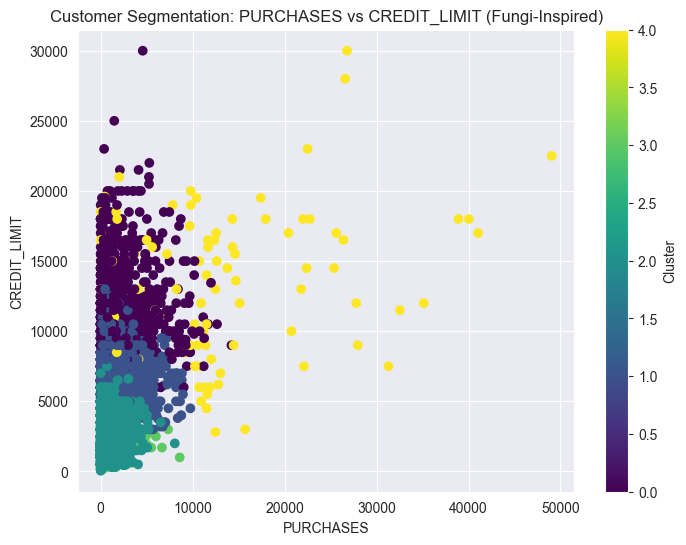

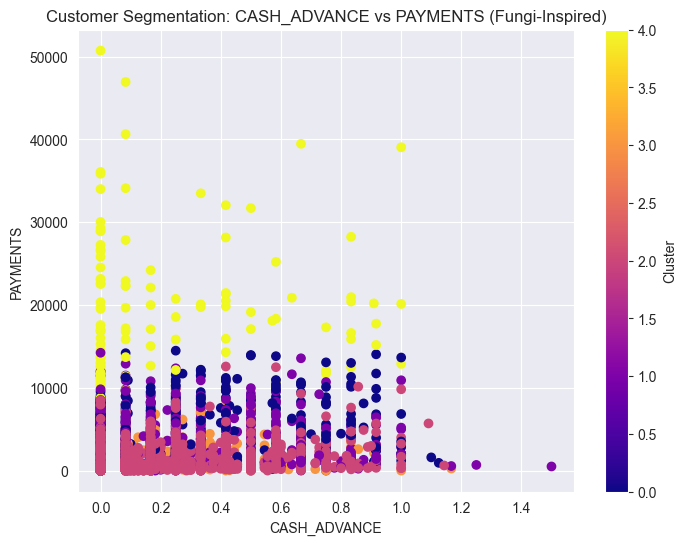

In [32]:
# Función para calcular la distancia euclidiana entre dos puntos
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(euclidean_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

In [33]:
df=df.drop(columns=['Cluster'])

Coeficiente de Silhouette: 0.3008663608596829

Centroides finales:
[[ 3.02479400e+03  4.56224865e+03  1.24553957e+03  3.53905350e-02
  -1.69646793e+00 -1.64212647e+00  1.85368791e+01  1.05777214e+04
   2.33715265e+03 -1.19873682e+00  1.16069818e+01  7.01739591e-02]
 [ 3.19613421e+03  2.42157846e+03  4.09365655e+03  1.96555118e+00
   1.21851713e+00  5.18438199e-01  4.95515356e+01  8.08811982e+03
   7.36469506e+03  8.03084377e-01  1.20316842e+01  2.58760964e+00]
 [ 6.68575639e+03  7.85027334e+02  5.41695689e+02  1.81501400e+00
   1.92350074e+00  1.98542978e+00  8.34509374e+00  2.57066831e+03
   9.51184033e+02 -1.12551527e+00  9.39532716e+00  4.54702660e-01]
 [ 2.23259943e+03  1.23464876e+03  7.34126926e+02  1.57178334e+00
  -1.25888003e+00 -8.51189022e-01  1.33911730e+01  3.94326930e+03
   1.20701043e+03 -1.09070447e+00  1.03912732e+01  1.52231635e+00]
 [ 2.23236804e+03  6.55911847e+03  1.61022582e+04  2.66513115e-01
   2.04270784e+00  1.34759598e+00  9.96629018e+01  1.63417617e+04
   2.

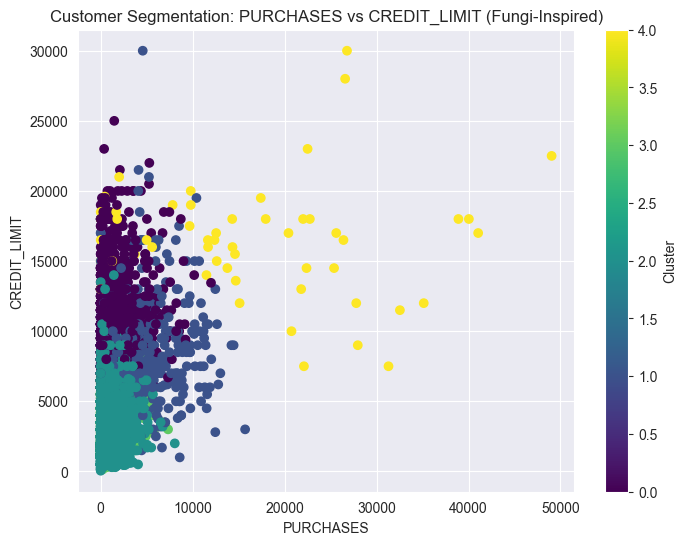

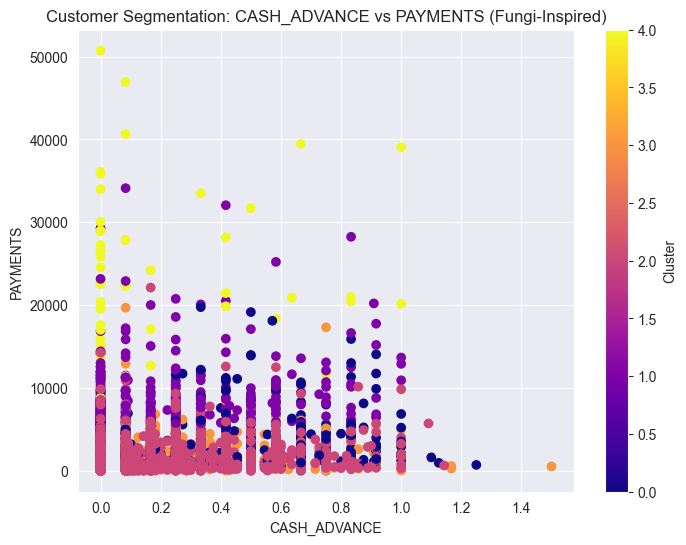

In [35]:
# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(manhattan_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

In [36]:
df=df.drop(columns=['Cluster'])

Coeficiente de Silhouette: 0.29451518599057086

Centroides finales:
[[ 2.82138570e+03  4.83493660e+03  1.98365898e+03  7.80210946e-01
   1.12733185e+00 -1.04648810e+00  2.41613270e+01  1.13654039e+04
   3.71384262e+03  3.37866600e-01  1.11447060e+01]
 [ 3.60565006e+03  1.77045595e+03  1.25650625e+03  3.04221571e-01
   1.85029560e-01 -1.20937651e+00  2.06269145e+01  6.56476347e+03
   2.02374453e+03  1.55027434e-01  1.22986696e+01]
 [ 7.08337844e+03  7.10602406e+02  5.08483516e+02  8.06153082e-01
  -1.54626256e+00  1.36547825e+00  8.20596749e+00  2.17209105e+03
   8.59400058e+02  7.79050187e-01  1.09837340e+01]
 [ 2.40706743e+03  1.01516518e+03  5.40176681e+02  1.93320718e+00
   4.16401763e-01  4.67473762e-02  8.72381329e+00  2.38616724e+03
   9.49663169e+02 -6.66156595e-01  9.60424877e+00]
 [ 2.46923034e+03  4.60033068e+03  1.07697498e+04  3.26145766e-01
   1.01137242e+00  1.32978372e+00  7.84960219e+01  1.26676762e+04
   1.93582772e+04  8.62325508e-01  1.30504914e+01]]

Tamaño de cada 

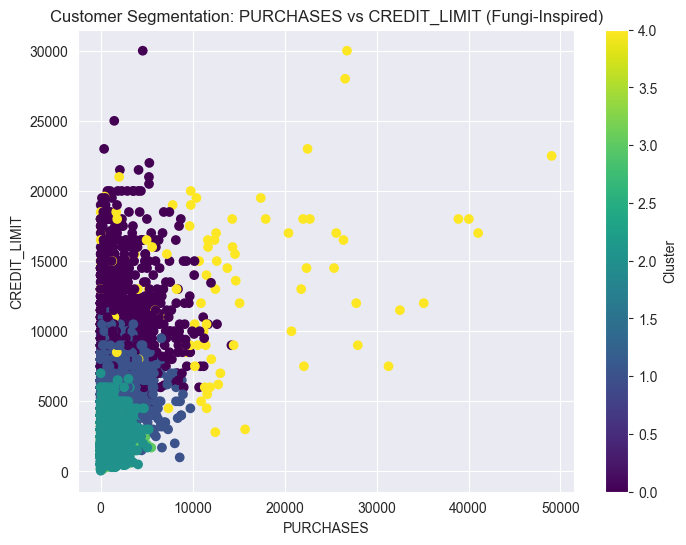

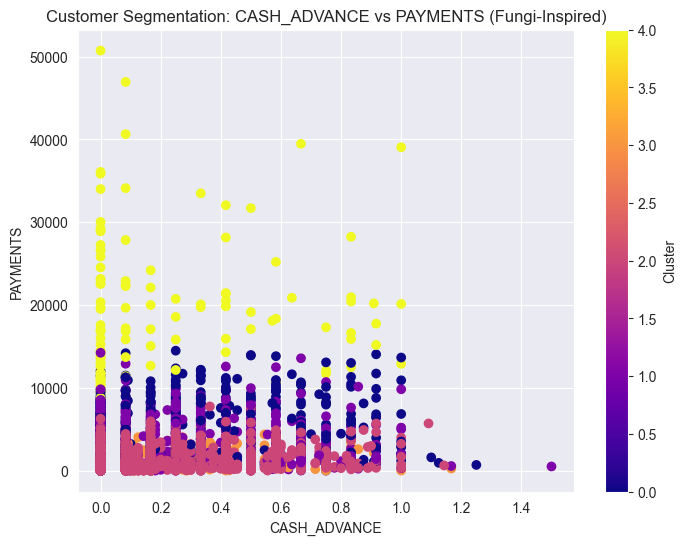

In [37]:
n_clusters = 5
fungi_clustering = FungiInspiredClustering(minkowski_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

# Selección de Características Tomando En Cuenta Matriz de Correlación y la PCA

In [39]:
df = pd.read_csv(file_path)
df= df.drop(columns=['ONEOFF_PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_TRX','TENURE','CASH_ADVANCE','BALANCE_FREQUENCY'])

Coeficiente de Silhouette: 0.2842887906619988

Centroides finales:
[[ 2.83144782e+03  5.20250441e+03  1.98170139e+03  1.22866041e+03
   7.53799878e+02 -7.27209751e-01 -1.40441954e+00  2.55861295e+01
   1.20881131e+04  3.83751625e+03 -5.30037224e-01]
 [ 3.44274684e+03  1.97823094e+03  1.35520779e+03  8.44128155e+02
   5.10666716e+02 -8.00035719e-01  2.03284033e+00  1.96673806e+01
   6.92961624e+03  2.18014033e+03  7.24905742e-01]
 [ 7.02374317e+03  7.20880052e+02  5.09596795e+02  2.31698172e+02
   2.78982502e+02  1.72072083e+00 -1.49991808e+00  8.73212195e+00
   2.25571747e+03  8.99075869e+02 -7.06543143e-02]
 [ 2.38395294e+03  1.03181914e+03  5.33159749e+02  2.86184638e+02
   2.49024421e+02  3.63305219e-01 -7.57706209e-01  1.11285368e+01
   2.49613889e+03  9.72371910e+02 -1.85916714e+00]
 [ 2.44083890e+03  4.70380053e+03  1.14512255e+04  8.18933534e+03
   3.26370903e+03  1.87569223e+00 -1.68964740e+00  8.78547917e+01
   1.25101103e+04  1.86717320e+04  1.59083355e+00]]

Tamaño de cada c

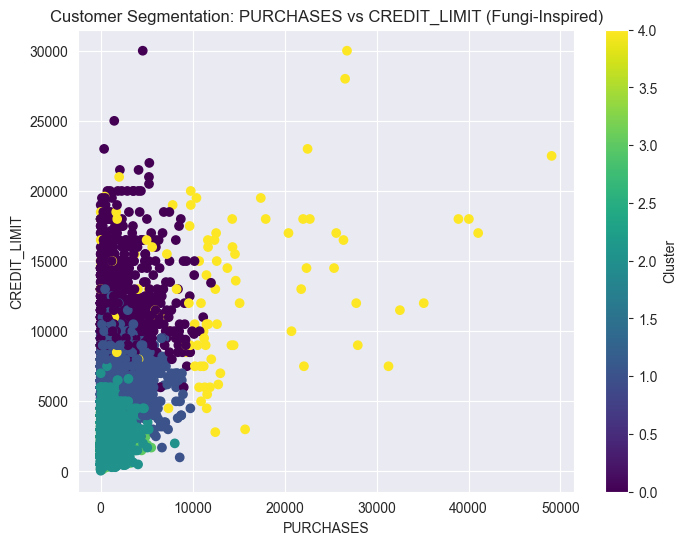

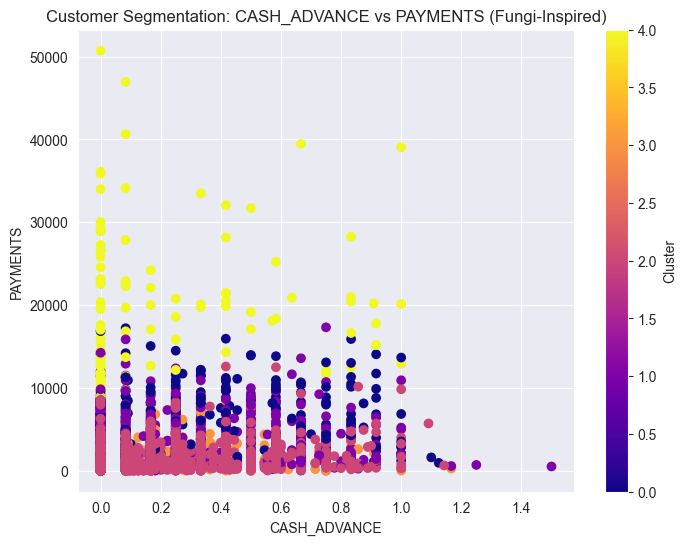

In [41]:
# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(euclidean_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.34459695768028625

Centroides finales:
[[ 2.66793876e+03  7.09854986e+03  1.73935468e+03  1.02504906e+03
   7.12043882e+02 -1.35915244e+00  5.07314690e-01  2.61009376e+01
   1.33689208e+04  5.63365016e+03 -4.00142513e-02  3.20389440e-01]
 [ 3.07318398e+03  2.57649344e+03  7.30483480e+03  4.93897563e+03
   2.36981635e+03  1.26710678e+00  1.16150660e-01  8.04685147e+01
   8.47503116e+03  7.25843406e+03  4.88677355e-01  2.88374157e+00]
 [ 5.23139561e+03  8.58486291e+02  5.28568838e+02  2.59535267e+02
   2.71478158e+02  2.31737575e+00 -1.48716814e+00  1.01766458e+01
   2.56037138e+03  9.77893124e+02 -1.73621048e+00  7.47443098e-01]
 [ 2.87951856e+03  2.42702139e+03  1.13505737e+03  6.78405292e+02
   4.55312307e+02 -4.18947181e-01  1.31479104e+00  1.60895263e+01
   7.74623179e+03  2.20043106e+03 -1.15338919e+00 -4.52092394e-01]
 [ 2.02280045e+03  5.55411830e+03  2.75620023e+04  2.22622114e+04
   5.29888808e+03  2.07291636e+00 -3.91403537e-02  1.31153042e+02
   1

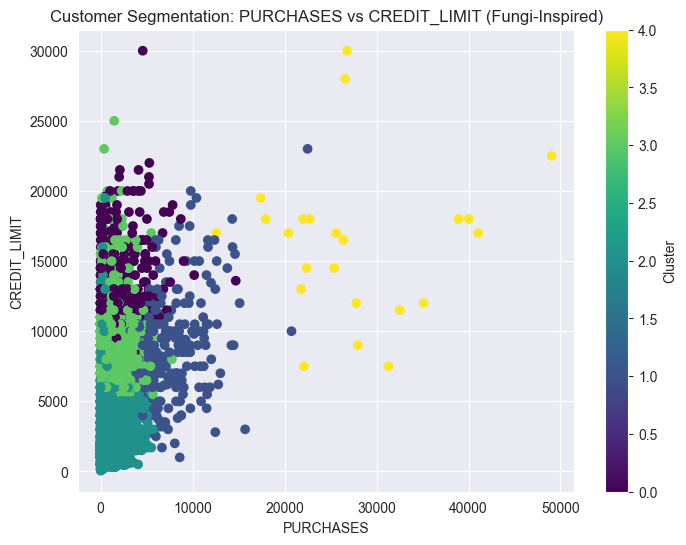

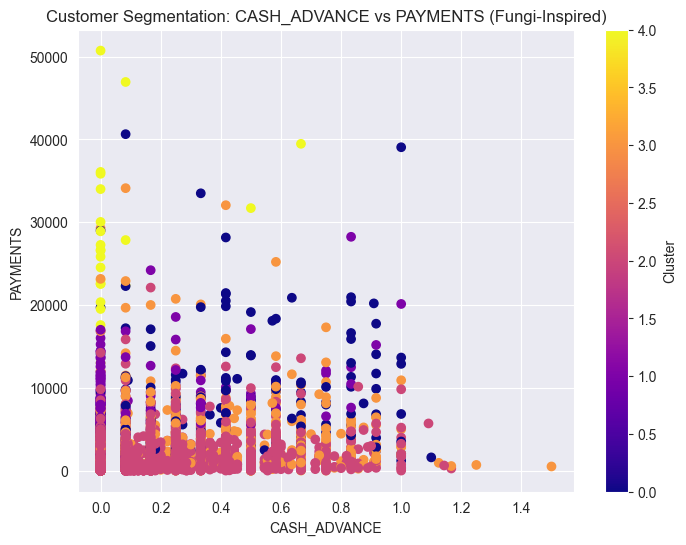

In [42]:
# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(manhattan_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.2788694181304491

Centroides finales:
[[ 2.83394772e+03  4.74074653e+03  1.99786432e+03  1.27778329e+03
   7.17642565e+02 -1.33823813e+00  4.34486167e-01  2.72778997e+01
   1.12471780e+04  3.75926764e+03  6.48683203e-03  1.77034403e+00]
 [ 3.61435398e+03  1.75954248e+03  1.21474373e+03  7.36804582e+02
   4.80156160e+02  8.87880002e-01  1.61854359e-01  1.73479749e+01
   6.53110772e+03  1.98163811e+03  3.39170806e-01  4.20014183e+00]
 [ 7.08405931e+03  7.10038339e+02  5.08419624e+02  2.29443123e+02
   2.81525605e+02  2.34275894e+00 -1.48541549e+00  1.02928080e+01
   2.16823249e+03  8.54509355e+02 -1.72277005e+00  4.57925639e-01]
 [ 2.41079344e+03  1.01146870e+03  5.29347223e+02  2.83597178e+02
   2.44471423e+02 -5.40498983e-01  1.25214260e+00  8.16282261e+00
   2.37077238e+03  9.40615787e+02 -1.19122437e+00  6.13001014e-01]
 [ 2.37864683e+03  4.70271947e+03  1.11104664e+04  7.89203900e+03
   3.21770784e+03  1.91694745e+00  1.05795031e-01  8.57617376e+01
   1.

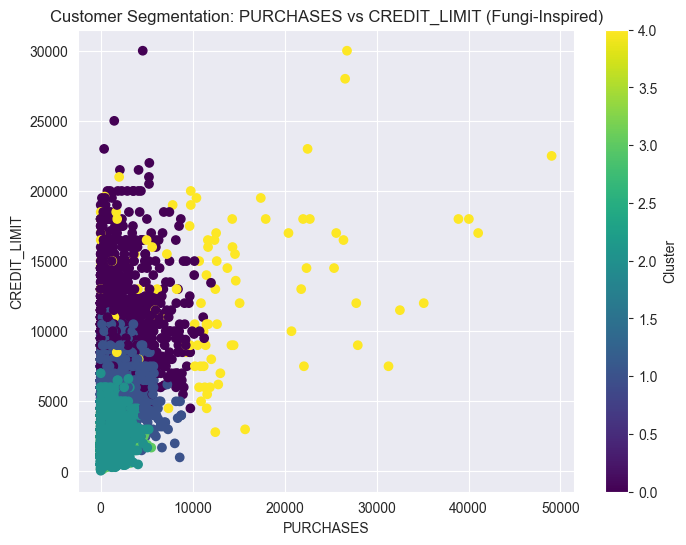

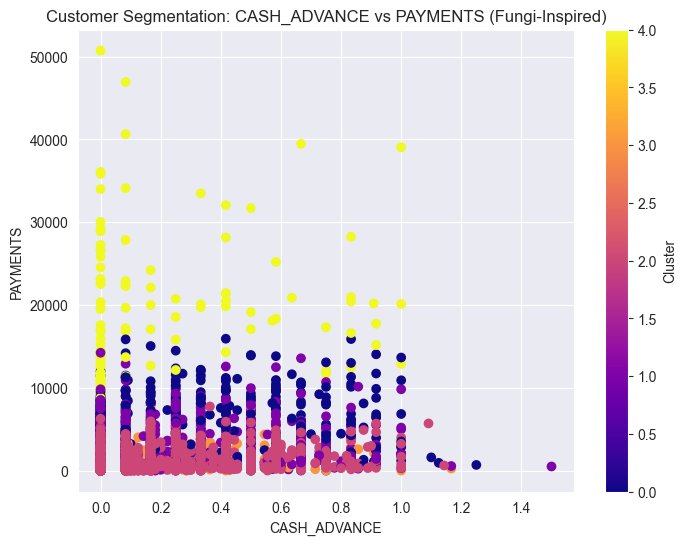

In [43]:
n_clusters = 5
fungi_clustering = FungiInspiredClustering(minkowski_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()